# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pandas as pd

# Open the data

In [2]:
df_combined = pd.read_csv('data/combined_dataframe.csv')

In [3]:
df_combined.head()

,iFRAP,mean_list_interp_bleached,mean_list_interp_unbleached,background_int,unfrap_cell,nucleus,frame,replicate,cell_type,depletion
0,0.021862,277.638710,275.858974,111.0,251.776607,1,0,20240503_FRAP_RAD21_WT,WT,WT
1,0.096636,287.141935,279.275000,111.0,251.776607,1,1,20240503_FRAP_RAD21_WT,WT,WT
2,0.031173,257.798701,260.337500,111.0,251.887754,1,2,20240503_FRAP_RAD21_WT,WT,WT
3,0.035072,266.653846,263.797468,111.0,251.887754,1,3,20240503_FRAP_RAD21_WT,WT,WT
4,1.079228,118.415584,206.311688,111.0,251.887754,1,4,20240503_FRAP_RAD21_WT,WT,WT


In [ ]:
# the average background intensity is used to normalize the FRAP data
df_avg_back = pd.read_csv('data/average_background_intensity.csv',index_col=0)

In [5]:
df_avg_back.head()

,0,1,2,3,4,5,6,7,8,9,...,240,241,242,243,244,245,246,247,248,249
20240503_FRAP_RAD21_WT,0.999996,0.998956,0.997351,1.003697,0.964094,0.958874,0.967956,0.951241,0.963503,0.950663,...,0.887898,0.888408,0.873995,0.889091,0.881926,0.887534,0.886080,0.884215,0.893164,0.881730
20240222_FRAP_RAD21_WT_LP_30,1.003122,0.993469,1.009985,0.993425,0.943765,0.936799,0.926688,0.920336,0.910613,0.927981,...,0.884276,0.914973,0.903791,0.903356,0.896009,0.903654,0.907536,0.889347,0.910681,0.906181
20240429_FRAP_RAD21_WT,1.014074,0.992867,0.998646,0.994413,0.979231,0.977649,0.973321,0.982974,0.972373,0.987949,...,0.934413,0.919224,0.933670,0.922683,0.943736,0.948539,0.945942,0.944269,0.936610,0.939674
20240116_NIPBL_FKBP_nodtag_30_LP_1,1.004844,1.002823,1.000372,0.991961,0.951061,0.957226,0.949602,0.959653,0.947044,0.950127,...,0.958457,0.957016,0.960012,0.963814,0.964938,0.953183,0.956389,0.953087,0.958644,0.964989
20240201_NIPBL_FKBP_nodtag_30_LP_1_s1,0.999087,0.999229,1.002318,0.999366,1.016489,1.006052,1.011554,1.015253,1.003754,1.005788,...,0.942797,0.941649,0.937730,0.942912,0.931055,0.946505,0.931299,0.942406,0.939088,0.932106


In [6]:
unique_comb = [('WT', 'WT'),
 ('NIPBL', '- dtag'),
 ('NIPBL', '+ dtag'),
 ('WAPL', '- aux'),
 ('WAPL', '+ aux'),
 ('PDS5', '- aux'),
 ('PDS5', '+ aux')]

In [7]:
# compute the iFRAP curves

j = 5 # index of the time point to normalize the data to (t0)
t0 = j*0.5 # time point corresponding to t0 in seconds

dfs=[]
ifraps = []
sds = []

for comb in unique_comb: # loop over all combinations of cell type and depletion
    d = df_combined[(df_combined.cell_type == comb[0]) & (df_combined.depletion == comb[1])]
    list_sample = []
    print(len(d.nucleus.unique())) # number of nuclei in the combination

    for i in d.replicate.unique(): # loop over all the images in the combination
        x = np.arange(0,125,0.5)
        correction_bleaching =  df_avg_back[df_avg_back.index == i].values[0] # get the average background intensity for the replicate

        df = d[d.replicate == i].iloc[:,:-3].groupby('frame').mean().reset_index() # average the data over all nuclei in the replicate

        y = ((df.mean_list_interp_unbleached-df.mean_list_interp_bleached)/correction_bleaching) # iFRAP signal
        norm = y[j]
        y = y/norm # normalize the data to the value at t0
        y = y[j:]
        
        list_sample.append(y.values)
    ifraps.append(np.mean(list_sample,axis=0)) # compute the average iFRAP curve for the combination

    sds.append(np.std(list_sample,axis=0)) # compute the standard deviation iFRAP curve for the combination

18
18
16
23
16
20
12


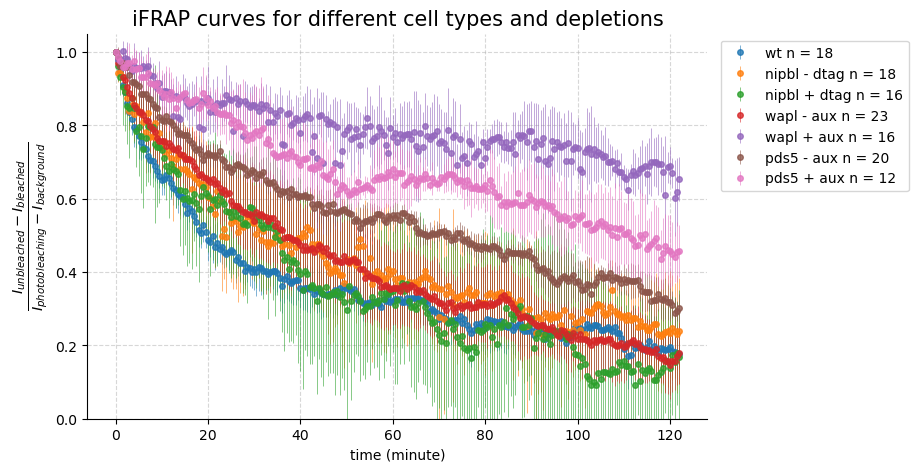

In [ ]:
fig,ax = plt.subplots(figsize=(8,5))

# With error bars

times = np.arange(0,((250-j)*0.5),0.5) # time points corresponding to the iFRAP curves

for i,label,s in zip(ifraps,['wt n = 18','nipbl - dtag n = 18','nipbl + dtag n = 16','wapl - aux n = 23','wapl + aux n = 16','pds5 - aux n = 20','pds5 + aux n = 12'],sds):

    plt.errorbar(times,i,s,label=label,elinewidth=0.5,capsize=0,lw=2,alpha=0.8,linestyle='',marker='o',markersize=4)

plt.legend(bbox_to_anchor=(1.01, 1))
plt.xlabel('time (minute)')
plt.ylabel(r'$\frac{I_{unbleached}-I_{bleached}}{I_{photobleaching}-I_{background}}$',fontsize=15)
plt.ylim(0,1.05)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.title('iFRAP curves for different cell types and depletions',fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()